In [21]:
### CITATIONS ###
# I read through and utilized the following references to help me understand and set up the neural network. #
# https://medium.com/@a.r.amouzad.m/how-to-get-state-of-the-art-result-on-graph-classification-with-gnn-73afadff5d49
# https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb
# https://blog.dataiku.com/graph-neural-networks-part-three

In [2]:
!pip install torch
!pip install torch_geometric

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/13/85/6c1092d4b06c3db1ed23d4106488750917156af0b24ab0a2d9951830b0e9/torch-2.7.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for typing-extensions>=4.10.0 from https://files.pythonhosted.org/packages/8b/54/b1ae86c0973cc6f0210b53d508ca3641fb6d0c56823f288d108bc7ab3cc8/typing_extensions-4.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d0a6c10b75bf356191/sympy-1.14.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/212.5 MB ? eta -:--:--
   ---------------------------------------- 0.2/212.5 MB 4.6 MB/s eta 0:00:47
   ---------------------------------------- 0.9/212.5 MB 9.7 MB/s eta 0:00:22
    --------------------------------------- 2.8/212.5 MB 19.6 MB/s eta 0:00:11
    --------------------------------------- 4.9/212.5 MB 2

  Obtaining dependency information for torch_geometric from https://files.pythonhosted.org/packages/03/9f/157e913626c1acfb3b19ce000b1a6e4e4fb177c0bc0ea0c67ca5bd714b5a/torch_geometric-2.6.1-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/63.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/63.1 kB ? eta -:--:--
     ------ --------------------------------- 10.2/63.1 kB ? eta -:--:--
     ------------------ ------------------- 30.7/63.1 kB 262.6 kB/s eta 0:00:01
     ------------------------------ ------- 51.2/63.1 kB 327.7 kB/s eta 0:00:01
     -------------------------------------- 63.1/63.1 kB 338.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.1/1.1 MB 3.6 MB/s eta 0:00:01
   -------------------- ------------------- 0.6/1.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 10.3 MB/s eta 0:00:00


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np
import time
import random
import networkx as nx
import optuna
from optuna.samplers import TPESampler
from gwgraphs import *
from visualizations import GCNResultsVisualizer, get_model_probabilities

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
class GraphNeuralNetwork(nn.Module):

  def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3):
    super(GraphNeuralNetwork, self).__init__()

    self.num_layers = num_layers
    self.convs = nn.ModuleList()

    # First layer
    self.convs.append(GCNConv(input_dim, hidden_dim))

    # Hidden layers
    for _ in range(num_layers - 2):
      self.convs.append(GCNConv(hidden_dim, hidden_dim))

    # Last layer
    self.convs.append(GCNConv(hidden_dim, hidden_dim))

    # Classifier
    self.classifier = nn.Linear(hidden_dim, output_dim)
    self.dropout = nn.Dropout(0.5)

  def forward(self, x, edge_index, batch, edge_attr=None):
    # Apply GCN layers
    for i, conv in enumerate(self.convs):
      x = conv(x, edge_index, edge_weight=edge_attr)
      if i < len(self.convs) - 1:
        x = F.relu(x)
        x = self.dropout(x)

    # Global pooling to get graph-level representation
    x = global_mean_pool(x, batch)

    # Final classification
    x = self.classifier(x)

    return x


def train_model(model, train_loader, optimizer, criterion, device):
  """Function to train the model for one epoch."""
  model.train()
  total_loss = 0

  for batch in train_loader:
    batch = batch.to(device)
    optimizer.zero_grad()

    # Forward pass
    out = model(batch.x, batch.edge_index, batch.batch, batch.edge_attr if hasattr(batch, 'edge_attr') else None)

    # Convert labels from {-1, 1} to {0,1} for cross-entropy loss
    labels = (batch.y + 1) // 2

    loss = criterion(out, labels.view(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(train_loader)


def evaluate_model(model, test_loader, device):
  """Function to evaluate the model."""
  model.eval()
  predictions = []
  true_labels = []

  with torch.no_grad():
    for batch in test_loader:
      batch = batch.to(device)
      out = model(batch.x, batch.edge_index, batch.batch, batch.edge_attr if hasattr(batch, 'edge_attr') else None)

      # Get predictions
      pred = torch.argmax(out, dim=1)
      # Convert back to {-1,1} labels
      pred = pred * 2 - 1

      predictions.extend(pred.cpu().numpy())
      true_labels.extend(batch.y.cpu().numpy())

    return np.array(predictions), np.array(true_labels)


def calculate_metrics(y_true, y_pred):
  """Calculate classification metrics"""
  # Overall accuracy
  overall_acc = accuracy_score(y_true, y_pred)

  # By-class accuracy
  class_1_mask = y_true == 1
  class_neg1_mask = y_true == -1

  class_1_acc = accuracy_score(
      y_true[class_1_mask],
      y_pred[class_1_mask]) if np.sum(class_1_mask) > 0 else 0
  class_neg1_acc = accuracy_score(
      y_true[class_neg1_mask],
      y_pred[class_neg1_mask]) if np.sum(class_neg1_mask) > 0 else 0

  # F1 score
  f1 = f1_score(y_true, y_pred, average='weighted')

  return overall_acc, class_1_acc, class_neg1_acc, f1


def networkx_to_pyg(nx_graph, label, num_features):
  """Convert NetworkX graph to PyTorch Geometric Data object with edge features"""
  num_nodes = len(nx_graph.nodes)

  if num_features == 0:
    raise ValueError(
        "num_features cannot be 0. Use num_features=1 for minimal features.")
  elif num_features == 1:
    # Use constant features (all ones) for graphs without meaningful node features
    x = torch.ones(num_nodes, 1)
  else:
    # Create random node features for synthetic examples
    x = torch.randn(num_nodes, num_features)

  # Convert edges to tensor format and create edge features
  edge_list = list(nx_graph.edges())
  if len(edge_list) == 0:
    # Handle graphs with no edges
    edge_index = torch.empty((2, 0), dtype=torch.long)
    edge_attr = torch.empty((0, 1), dtype=torch.float)
  else:
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    
    # Create edge features based on graph properties
    edge_features = []
    for u, v in edge_list:
      # Use degree difference as edge feature
      degree_diff = abs(nx_graph.degree[u] - nx_graph.degree[v])
      edge_features.append([degree_diff])
    
    edge_attr = torch.tensor(edge_features, dtype=torch.float)

  # Convert label to tensor
  y = torch.tensor([label], dtype=torch.long)

  return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


def objective(trial, full_graph_data, device, input_dim, hidden_dim, output_dim):
    """Objective function for Bayesian optimization"""
    # Suggest hyperparameters
    num_epochs = trial.suggest_int('num_epochs', 20, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # 5-fold cross validation for this trial
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    for fold, (train_idx, test_idx) in enumerate(kfold.split(full_graph_data)):
        # Split data
        train_graphs = [full_graph_data[i] for i in train_idx]
        test_graphs = [full_graph_data[i] for i in test_idx]

        # Create data loaders
        train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

        # Initialize model
        model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()

        # Training loop
        for epoch in range(num_epochs):
            train_loss = train_model(model, train_loader, optimizer, criterion, device)

        # Evaluation
        y_pred, y_true = evaluate_model(model, test_loader, device)
        overall_acc, _, _, _ = calculate_metrics(y_true, y_pred)
        fold_scores.append(overall_acc)

        # Report intermediate objective value for pruning
        trial.report(np.mean(fold_scores[:fold + 1]), fold)

        # Handle pruning based on the intermediate value
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_scores)

In [4]:
### ERSBM1 EXPERIMENT: MORE TRAINING DATA ###
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model parameters
input_dim = 1  # Number of node features; no meaningful features in this synthetic example, so set = 1
hidden_dim = 64  # defines the number of neurons in the GCN layers. Essentially, controls the width of the neural network
# larger hidden_dim means more capacity but more parameters
output_dim = 2  # Binary classification, so set to 2

# Generate and process data
print("Generating synthetic graph dataset...")
# Generate ERSBM1
prob_matrix = [
    [0.15, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.15]  # Probabilities related to block 2 connections
]

graphs_er = generate_erdos_renyi_graphs(500, 100, 0.1)
graphs_sbm = generate_sbm_graphs(500, [50, 50], prob_matrix)

# Convert NetworkX graphs to PyTorch Geometric Data objects
full_graph_data = []
graphs_list = []
labels_list = []
for nx_graph, label in graphs_er + graphs_sbm:
  pyg_data = networkx_to_pyg(nx_graph, label, input_dim)
  full_graph_data.append(pyg_data)
  graphs_list.append(nx_graph)
  labels_list.append(label)

# Extract labels for reference
labels = [data.y.item() for data in full_graph_data]
labels = np.array(labels)
print("ERSBM1 created")

print("\nStarting Bayesian Optimization for Hyperparameter Tuning...")
start_time = time.time()

# Create Optuna study
study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=42),
                            pruner=optuna.pruners.MedianPruner(
                                n_startup_trials=5, n_warmup_steps=2))

# Optimize hyperparameters
study.optimize(
    lambda trial: objective(trial, full_graph_data, device, input_dim,
                            hidden_dim, output_dim),
    n_trials=30
)

optimization_time = time.time() - start_time

# Print best hyperparameters
print("\n" + "=" * 60)
print("BAYESIAN OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best accuracy: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

print(f"\nOptimization time: {optimization_time:.2f} seconds")

# Train final model with best hyperparameters
print("\n" + "=" * 60)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("=" * 60)

best_params = study.best_trial.params
final_num_epochs = best_params['num_epochs']
final_learning_rate = best_params['learning_rate']
final_batch_size = best_params['batch_size']

# 5-fold cross validation with best parameters
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
all_results = []
fold_times = []

print("\nStarting 5-fold cross-validation with optimized parameters...")
total_start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(kfold.split(full_graph_data)):
  print(f"\n--- Final Training Fold {fold + 1}/5 ---")
  fold_start_time = time.time()

  # Split data
  train_graphs = [full_graph_data[i] for i in train_idx]
  test_graphs = [full_graph_data[i] for i in test_idx]

  # Create data loaders
  train_loader = DataLoader(train_graphs, batch_size=final_batch_size, shuffle=True)
  test_loader = DataLoader(test_graphs, batch_size=final_batch_size, shuffle=False)

  # Initialize model
  model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
  optimizer = optim.Adam(model.parameters(), lr=final_learning_rate)
  criterion = nn.CrossEntropyLoss()

  # Training loop
  for epoch in range(final_num_epochs):
    train_loss = train_model(model, train_loader, optimizer, criterion, device)

    if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch + 1}/{final_num_epochs}, Loss: {train_loss:.4f}")

  # Final evaluation
  y_pred, y_true = evaluate_model(model, test_loader, device)
  overall_acc, class_1_acc, class_neg1_acc, f1 = calculate_metrics(y_true, y_pred)

  fold_time = time.time() - fold_start_time
  fold_times.append(fold_time)

  results = {
      'fold': fold + 1,
      'overall_accuracy': overall_acc,
      'class_1_accuracy': class_1_acc,
      'class_-1_accuracy': class_neg1_acc,
      'f1_score': f1,
      'fold_time': fold_time
  }

  all_results.append(results)

  print(f"Results for Fold {fold + 1}:")
  print(f"  Overall Accuracy: {overall_acc:.4f}")
  print(f"  Class +1 Accuracy: {class_1_acc:.4f}")
  print(f"  Class -1 Accuracy: {class_neg1_acc:.4f}")
  print(f"  F1 Score: {f1:.4f}")
  print(f"  Fold Time: {fold_time:.2f} seconds")

# Calculate final average metrics
avg_overall_acc = np.mean([r['overall_accuracy'] for r in all_results])
avg_class_1_acc = np.mean([r['class_1_accuracy'] for r in all_results])
avg_class_neg1_acc = np.mean([r['class_-1_accuracy'] for r in all_results])
avg_f1 = np.mean([r['f1_score'] for r in all_results])

std_overall_acc = np.std([r['overall_accuracy'] for r in all_results])
std_class_1_acc = np.std([r['class_1_accuracy'] for r in all_results])
std_class_neg1_acc = np.std([r['class_-1_accuracy'] for r in all_results])
std_f1 = np.std([r['f1_score'] for r in all_results])

total_time = time.time() - total_start_time

print("\n" + "=" * 60)
print("FINAL RESULTS WITH OPTIMIZED HYPERPARAMETERS")
print("=" * 60)
print(f"Best hyperparameters used:")
print(f"  Epochs: {final_num_epochs}")
print(f"  Learning Rate: {final_learning_rate:.6f}")
print(f"  Batch Size: {final_batch_size}")
print(f"\nFinal Cross-Validation Results:")
print(f"Average Overall Accuracy: {avg_overall_acc:.4f} ± {std_overall_acc:.4f}")
print(f"Average Class +1 Accuracy: {avg_class_1_acc:.4f} ± {std_class_1_acc:.4f}")
print(f"Average Class -1 Accuracy: {avg_class_neg1_acc:.4f} ± {std_class_neg1_acc:.4f}")
print(f"Average F1 Score: {avg_f1:.4f} ± {std_f1:.4f}")
print(f"\nTotal Time (Optimization + Final Training): {total_time:.2f} seconds")
print(f"Average Time per Fold: {np.mean(fold_times):.2f} seconds")

Using device: cpu
Generating synthetic graph dataset...


[I 2025-06-27 16:54:29,257] A new study created in memory with name: no-name-98193ef1-e1c8-49da-8616-a235485ccae3


ERSBM1 created

Starting Bayesian Optimization for Hyperparameter Tuning...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader


BAYESIAN OPTIMIZATION RESULTS
Best trial: 21
Best accuracy: 0.6570
Best hyperparameters:
  num_epochs: 100
  learning_rate: 0.03403614029566116
  batch_size: 64

Optimization time: 4303.10 seconds

TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Starting 5-fold cross-validation with optimized parameters...

--- Final Training Fold 1/5 ---
Epoch 10/100, Loss: 0.6792
Epoch 20/100, Loss: 0.6715
Epoch 30/100, Loss: 0.6875
Epoch 40/100, Loss: 0.6855
Epoch 50/100, Loss: 0.6720
Epoch 60/100, Loss: 0.6801
Epoch 70/100, Loss: 0.6752
Epoch 80/100, Loss: 0.6732
Epoch 90/100, Loss: 0.6734
Epoch 100/100, Loss: 0.6658
Results for Fold 1:
  Overall Accuracy: 0.5200
  Class +1 Accuracy: 0.0000
  Class -1 Accuracy: 1.0000
  F1 Score: 0.3558
  Fold Time: 37.44 seconds

--- Final Training Fold 2/5 ---


...

Epoch 10/100, Loss: 0.6973
Epoch 20/100, Loss: 0.6931
Epoch 30/100, Loss: 0.6936
Epoch 40/100, Loss: 0.6933
Epoch 50/100, Loss: 0.6935
Epoch 60/100, Loss: 0.6934
Epoch 70/100, Loss: 0.6949
Epoch 80/100, Loss: 0.6954
Epoch 90/100, Loss: 0.6992
Epoch 100/100, Loss: 0.6934
Results for Fold 3:
  Overall Accuracy: 0.5300
  Class +1 Accuracy: 1.0000
  Class -1 Accuracy: 0.0000
  F1 Score: 0.3672
  Fold Time: 37.65 seconds

--- Final Training Fold 4/5 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 10/100, Loss: 0.6810
Epoch 20/100, Loss: 0.6645
Epoch 30/100, Loss: 0.6140
Epoch 40/100, Loss: 0.6359
Epoch 50/100, Loss: 0.6223
Epoch 60/100, Loss: 0.5786
Epoch 70/100, Loss: 0.6030
Epoch 80/100, Loss: 0.6021
Epoch 90/100, Loss: 0.5884
Epoch 100/100, Loss: 0.5847
Results for Fold 4:
  Overall Accuracy: 0.5750
  Class +1 Accuracy: 0.0000
  Class -1 Accuracy: 1.0000
  F1 Score: 0.4198
  Fold Time: 37.79 seconds

--- Final Training Fold 5/5 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 10/100, Loss: 0.6962
Epoch 20/100, Loss: 0.6949
Epoch 30/100, Loss: 0.6958
Epoch 40/100, Loss: 0.6936
Epoch 50/100, Loss: 0.6933
Epoch 60/100, Loss: 0.6939
Epoch 70/100, Loss: 0.6944
Epoch 80/100, Loss: 0.6975
Epoch 90/100, Loss: 0.6940
Epoch 100/100, Loss: 0.6932
Results for Fold 5:
  Overall Accuracy: 0.4950
  Class +1 Accuracy: 0.0000
  Class -1 Accuracy: 1.0000
  F1 Score: 0.3278
  Fold Time: 37.36 seconds

FINAL RESULTS WITH OPTIMIZED HYPERPARAMETERS
Best hyperparameters used:
  Epochs: 100
  Learning Rate: 0.034036
  Batch Size: 64

Final Cross-Validation Results:
Average Overall Accuracy: 0.5120 ± 0.0443
Average Class +1 Accuracy: 0.2000 ± 0.4000
Average Class -1 Accuracy: 0.8000 ± 0.4000
Average F1 Score: 0.3479 ± 0.0495

Total Time (Optimization + Final Training): 187.70 seconds
Average Time per Fold: 37.54 seconds


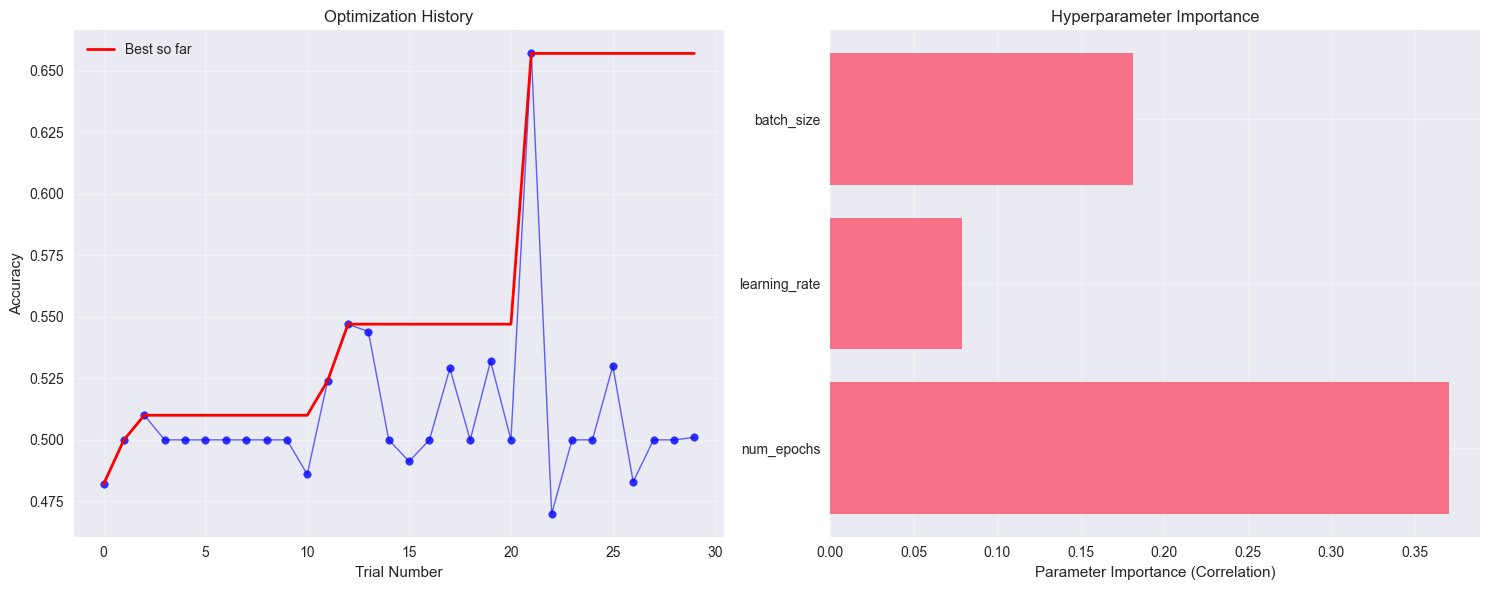

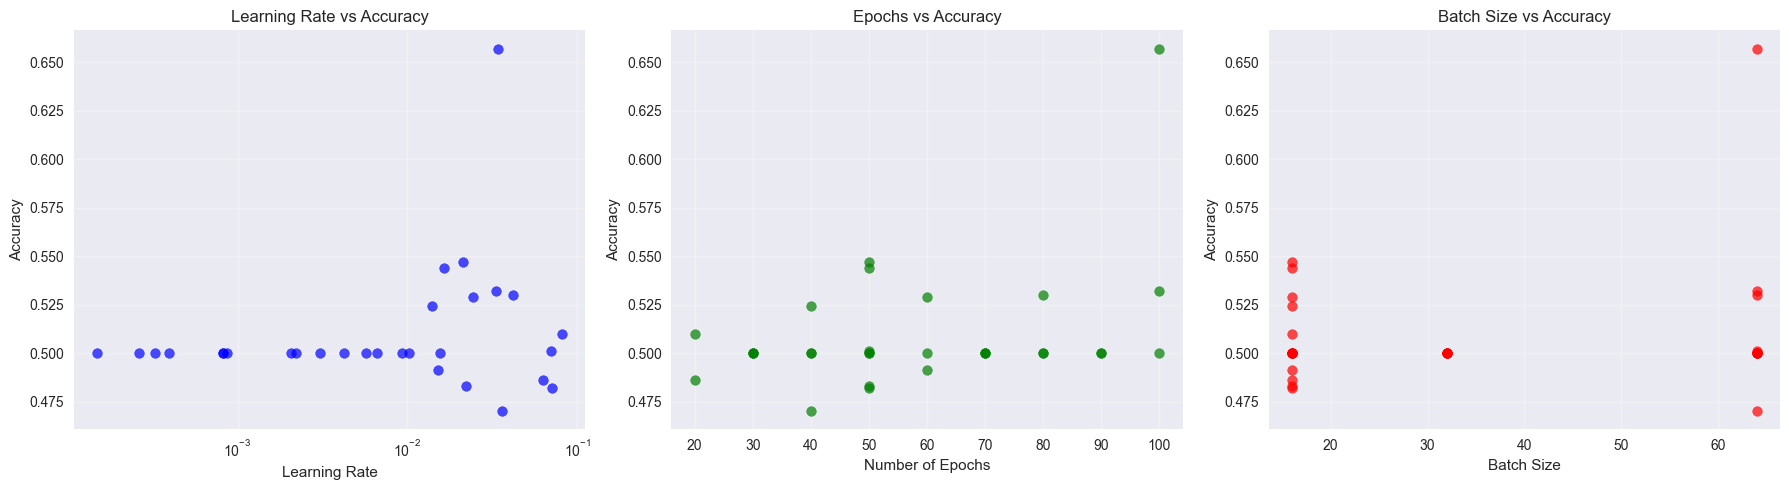

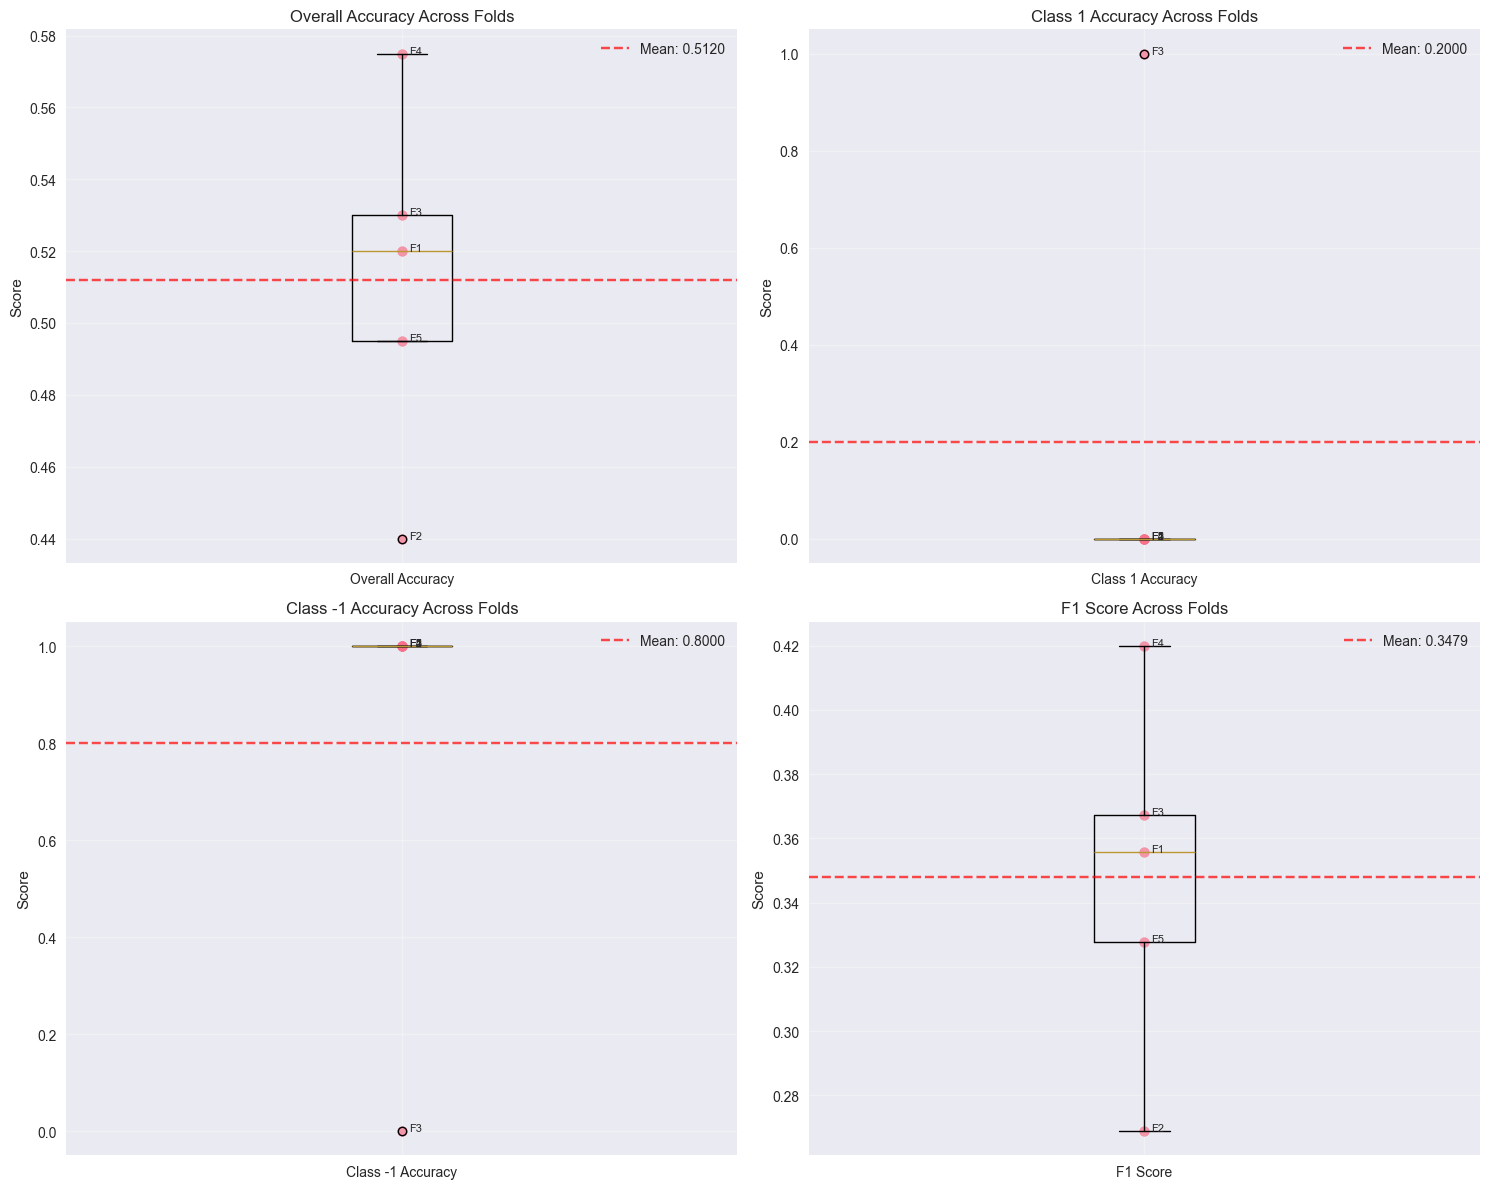


Training final model for detailed evaluation...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


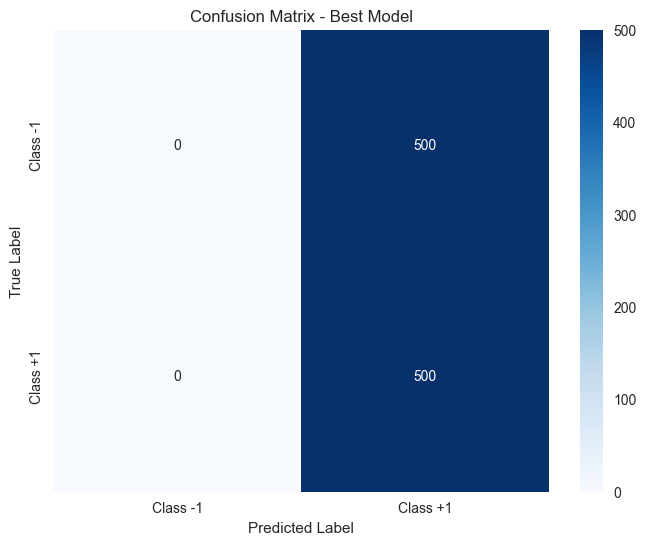

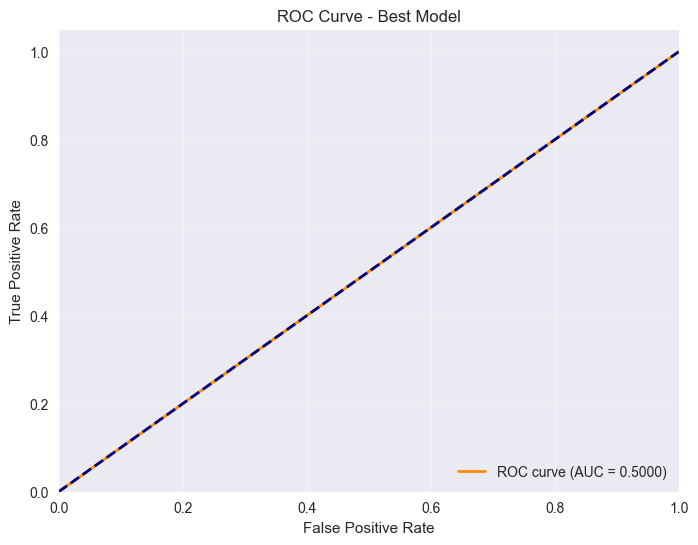

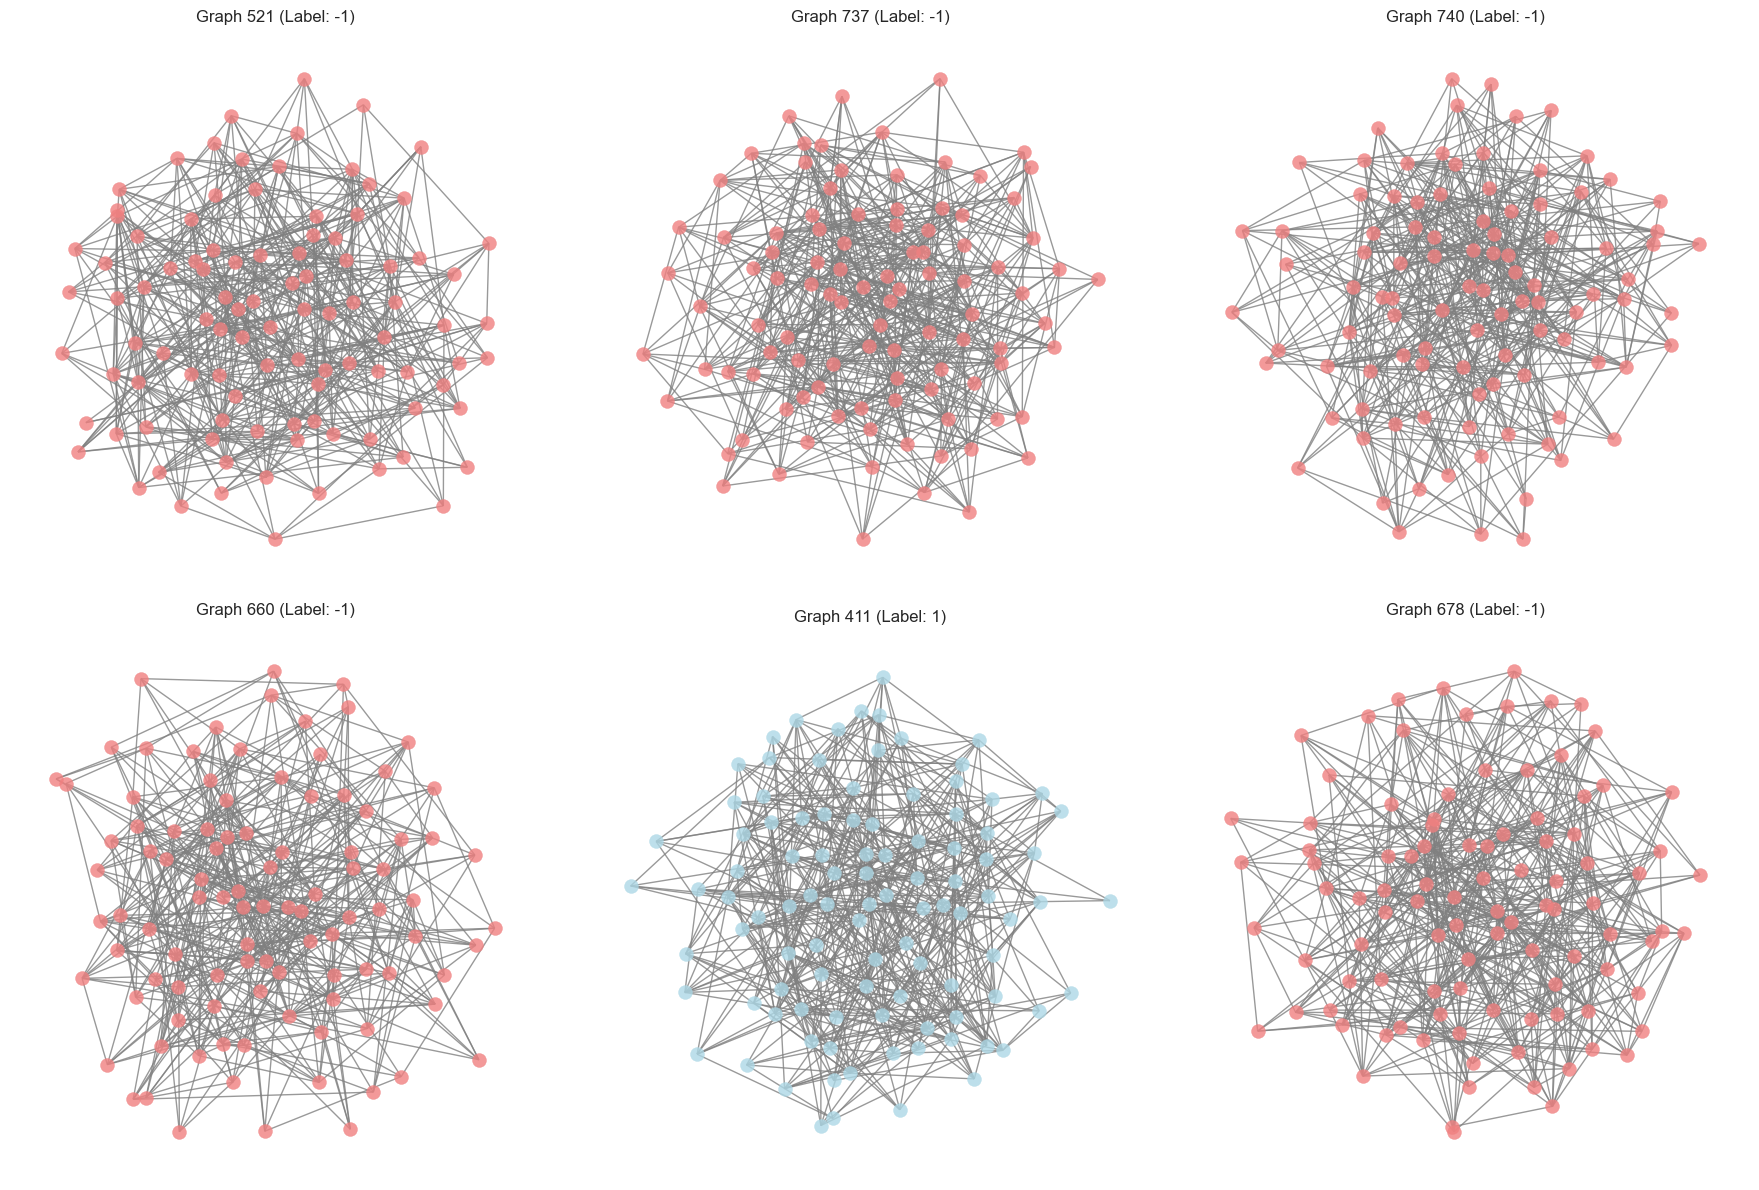

All visualizations have been generated and saved!


In [5]:
# Create visualizer with optimization results
visualizer = GCNResultsVisualizer(
    study=study, 
    all_results=all_results, 
    best_params=study.best_trial.params
)

# Generate core optimization visualizations
visualizer.plot_optimization_history()
visualizer.plot_hyperparameter_relationships()
visualizer.plot_cross_validation_results()

# For the final model evaluation with the best parameters
print("\nTraining final model for detailed evaluation...")

# Use the entire dataset for final model evaluation
final_train_loader = DataLoader(full_graph_data, batch_size=final_batch_size, shuffle=True)
final_model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=final_learning_rate)
final_criterion = nn.CrossEntropyLoss()

# Train the final model
for epoch in range(final_num_epochs):
    train_loss = train_model(final_model, final_train_loader, final_optimizer, final_criterion, device)

# Get predictions and probabilities for visualization
final_y_true, final_y_scores = get_model_probabilities(final_model, final_train_loader, device)
final_y_pred = np.argmax(final_y_scores, axis=1) * 2 - 1  # Convert back to {-1, 1}

# Generate performance visualizations
visualizer.plot_confusion_matrix(final_y_true, final_y_pred)
visualizer.plot_roc_curve(final_y_true, final_y_scores)

# Visualize sample graphs
visualizer.plot_sample_graphs(graphs_list, labels_list)

print("All visualizations have been generated and saved!")